<a href="https://colab.research.google.com/github/AnmolChetani/pricelens-ai/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/AnmolChetani/pricelens-ai.git

Cloning into 'pricelens-ai'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 52 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 19.26 KiB | 9.63 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [ ]:
%cd pricelens-ai

/content/pricelens-ai


In [ ]:
!ls

app  notebooks	README.md  requirements.txt  saved_models  src


In [ ]:
!git config --global user.name "AnmolChetani"
!git config --global user.email "anmolchetani@gmail.com"

In [ ]:
!mkdir -p notebooks

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Utility
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:

# Use python engine + skip bad lines
train_df = pd.read_csv(
    "/content/sample_data/train.csv",
    engine='python',
    on_bad_lines='skip'
)

test_df = pd.read_csv(
    "/content/sample_data/test.csv",
    engine='python',
    on_bad_lines='skip'
)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (73774, 4)
Test shape: (64548, 3)


In [5]:
train_df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [12]:
test_df.head()

,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73774 entries, 0 to 73773
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        73774 non-null  int64  
 1   catalog_content  73774 non-null  object 
 2   image_link       73774 non-null  object 
 3   price            73774 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB


In [8]:
train_df.isnull().sum()

,0
sample_id,0
catalog_content,0
image_link,0
price,0


In [9]:
test_df.isnull().sum()

,0
sample_id,0
catalog_content,0
image_link,0


In [10]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [11]:
train_df["price"].describe()

,price
count,73774.000000
mean,23.639431
std,33.351198
min,0.130000
25%,6.810000
50%,14.000000
75%,28.590000
max,2796.000000


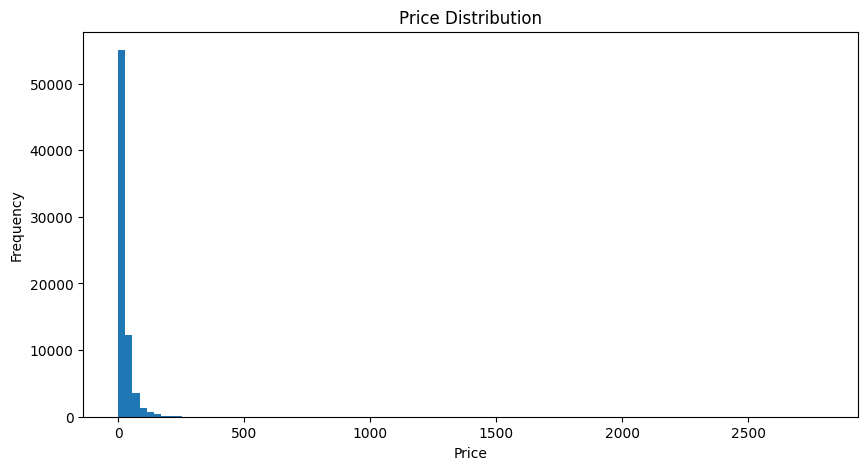

In [13]:
plt.figure(figsize=(10,5))

plt.hist(train_df["price"], bins=100)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")

plt.show()

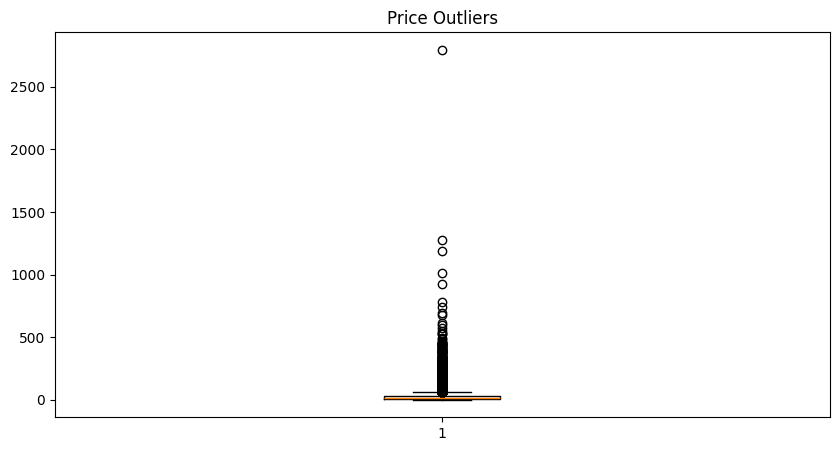

In [14]:
plt.figure(figsize=(10,5))

plt.boxplot(train_df["price"])

plt.title("Price Outliers")
plt.show()

In [15]:
for i in range(5):
    print(f"\nProduct {i+1}")
    print(train_df["catalog_content"].iloc[i])
    print("-" * 100)


Product 1
Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Value: 72.0
Unit: Fl Oz

----------------------------------------------------------------------------------------------------

Product 2
Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4)
Bullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter
Bullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total
Bullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries
Bullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family
Bullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925
Value: 32.0
Unit: Ounce

----------------------------------------------------------------------------------------------------

Product 3
Item Name: Bear Creek Hearty Soup Bowl, Creamy Chicken with Rice, 1.9 Ounce (Pack of 6)
Bullet Point 1: Loaded with hearty long grain wild rice and vegetables
Bu

In [16]:
train_df["text_length"] = train_df["catalog_content"].apply(len)

train_df["text_length"].describe()

,text_length
count,73774.000000
mean,909.663120
std,853.268166
min,32.000000
25%,251.000000
50%,644.000000
75%,1281.000000
max,7894.000000


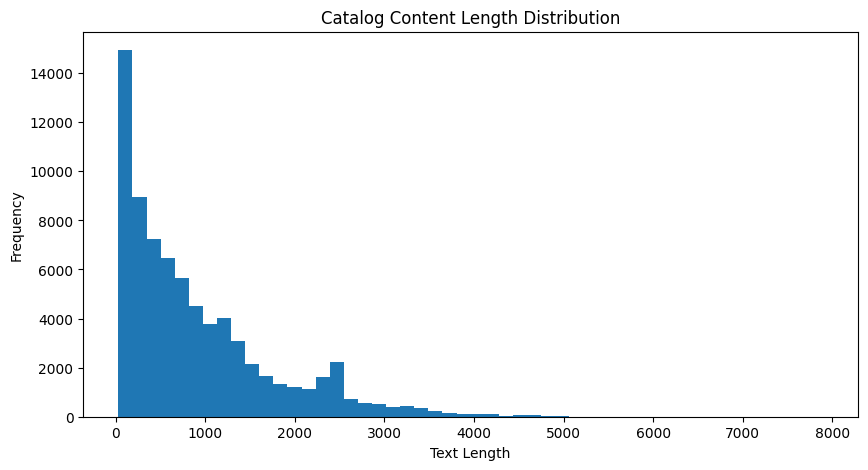

In [17]:
plt.figure(figsize=(10,5))

plt.hist(train_df["text_length"], bins=50)

plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Catalog Content Length Distribution")

plt.show()

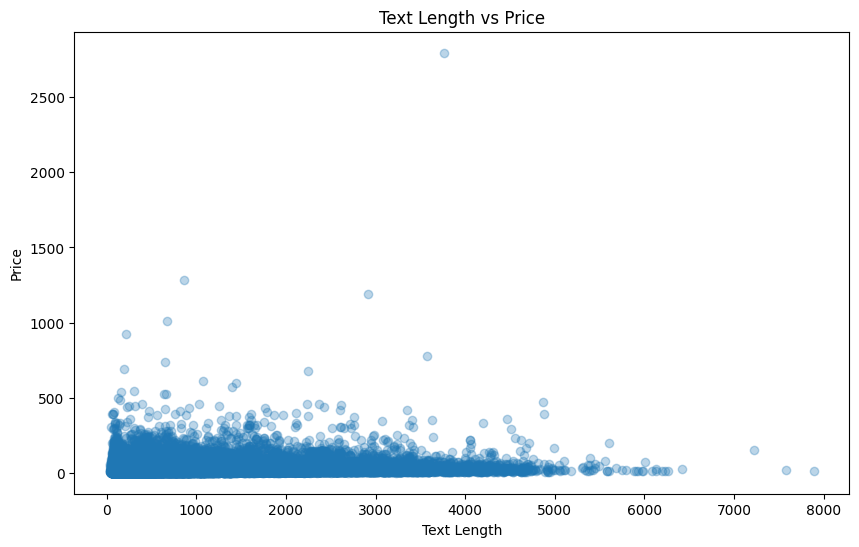

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    train_df["text_length"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Text Length")
plt.ylabel("Price")
plt.title("Text Length vs Price")

plt.show()

In [19]:
train_df[["text_length", "price"]].corr()

,text_length,price
text_length,1.00000,0.14631
price,0.14631,1.00000


In [20]:
import re

def extract_numbers(text):
    numbers = re.findall(r'\d+\.?\d*', text)
    return len(numbers)

train_df["num_count"] = train_df["catalog_content"].apply(extract_numbers)

train_df["num_count"].describe()

,num_count
count,73774.000000
mean,8.856535
std,5.188872
min,0.000000
25%,5.000000
50%,9.000000
75%,11.000000
max,89.000000


In [21]:
train_df[["num_count", "price"]].corr()

,num_count,price
num_count,1.000000,0.138125
price,0.138125,1.000000


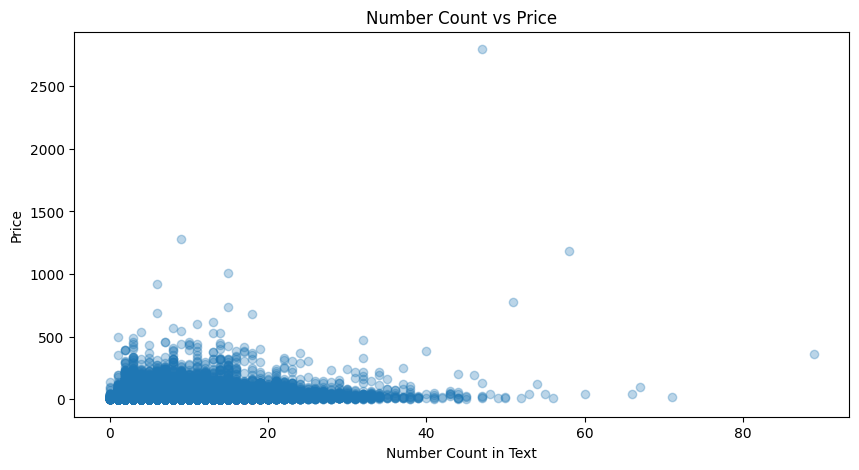

In [22]:
plt.figure(figsize=(10,5))

plt.scatter(
    train_df["num_count"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Number Count in Text")
plt.ylabel("Price")
plt.title("Number Count vs Price")

plt.show()